# Ejercicio 3: Clasificación de peligro a partir de probabilidades de excedencia

Cuatro rásteres, cada uno con la probabilidad de que la inundación alcance una
profundidad determinada. Este cuaderno los combina en una sola clasificación de
peligro y después calcula qué edificios y carreteras caen dentro de cada nivel.

La pregunta que se responde es distinta de la del Ejercicio 2:

> **¿Cuál es la probabilidad de que aquí haya al menos 30 cm de agua?**

El Ejercicio 2 muestreaba la *profundidad* de una tormenta específica. Este trabaja
con **probabilidades de excedencia** a lo largo de un conjunto, que es un producto
más útil para un pronóstico.

**Qué llevarse de este cuaderno**

- cómo cuatro capas anidadas de probabilidad se reducen a una sola clasificación, y
  por qué la regla asigna los niveles en orden ascendente
- por qué un umbral es una decisión de modelación y no un detalle, y por qué conviene
  revisar qué rango pueden alcanzar realmente los datos antes de exponer uno
- por qué las estadísticas zonales son una propiedad de la cuadrícula tanto como de
  la geometría

**Flujo de trabajo**

1. Clasificar los píxeles en niveles de peligro con la regla de umbrales escalonados
2. Descubrir una restricción en los datos que limita lo que puede significar el nivel
   más alto
3. Clasificar directamente los edificios y las carreteras
4. Armar la tabla de impacto

Todo se lee de un bucket público de S3. Nada se guarda localmente.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap

%matplotlib inline

BUCKET = "https://cog-s3-test-401506828094-us-east-1-an.s3.us-east-1.amazonaws.com"
PROB = {                              # copias en EPSG:3857, todas en una cuadrícula
    "7p62": f"{BUCKET}/PBI_Actividad_2/prob_7p62.tif",
    "10cm": f"{BUCKET}/PBI_Actividad_2/prob_10cm.tif",
    "30cm": f"{BUCKET}/PBI_Actividad_2/prob_30cm.tif",
    "76cm": f"{BUCKET}/PBI_Actividad_2/prob_76cm.tif",
}
FEATURES = f"{BUCKET}/Guatemala_IBF/impact_features.csv"

print("listo")

listo


## 1. Los cuatro rásteres de probabilidad

Cada ráster contiene **P(profundidad de inundación ≥ umbral)** para una profundidad,
generado a partir de un conjunto EF5. Un valor de celda de 0.3 en el ráster de 30 cm
significa *"en el 30% de los miembros del conjunto, el agua aquí alcanzó al menos
30 cm"*.

In [2]:
layers, meta = {}, {}
for name, url in PROB.items():
    with rasterio.open(url) as ds:
        layers[name] = ds.read(1, masked=True)
        meta[name] = {"crs": ds.crs, "shape": ds.shape,
                      "transform": ds.transform, "res": ds.res[0]}

for name, m in meta.items():
    print(f"prob_{name:<5} {m['crs']}  {m['shape']}  {m['res']:.0f} m")

shapes_seen = {v.shape for v in layers.values()}
print(f"\nlas cuatro comparten una sola cuadrícula: {len(shapes_seen) == 1}")

prob_7p62  EPSG:3857  (424, 319)  5 m
prob_10cm  EPSG:3857  (424, 319)  5 m
prob_30cm  EPSG:3857  (424, 319)  5 m
prob_76cm  EPSG:3857  (424, 319)  5 m

las cuatro comparten una sola cuadrícula: True


## 2. La regla de clasificación (repaso del cuaderno UFFIS)

Cada nivel de peligro está ligado a **una** capa de profundidad, y cada uno tiene su
propio umbral de probabilidad:

| nivel | determinado por | umbral inicial |
|---|---|---|
| Bajo | P(≥ 7.6 cm) | 0.8 |
| Medio | P(≥ 10 cm) | 0.8 |
| Alto | P(≥ 30 cm) | 0.8 |
| Severo | P(≥ 76 cm) | 0.2 |

Un píxel toma el nivel del umbral **más profundo** que logra superar. Eso sale de
asignar los niveles en orden ascendente y dejar que ganen las asignaciones
posteriores.

Esta es una traducción fiel de `clasificar_peligro` del cuaderno UFFIS.

> **Por qué el umbral Severo es 0.2 y no 0.8.** El ráster de 76 cm solo contiene los
> valores 0 y 0.2, así que ningún píxel puede superar un umbral más alto. Con 0.8, la
> clase Severo sería *inalcanzable* y el color simplemente nunca aparecería. Este es
> el punto de la sección siguiente.

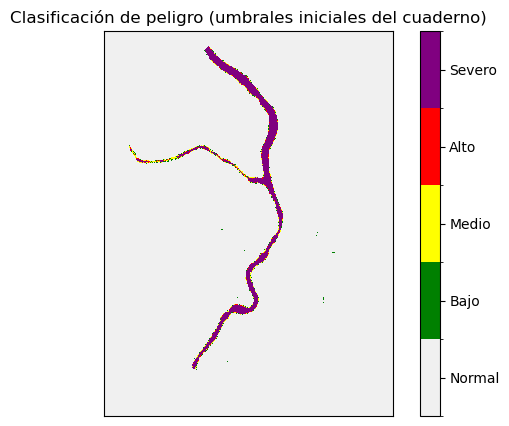

In [3]:
LEVELS = [(1, "green"), (2, "yellow"), (3, "red"), (4, "purple")]
LEVEL_LABEL = {0: "Normal", 1: "Bajo", 2: "Medio", 3: "Alto", 4: "Severo"}
NODATA = 255
ORDER = ["7p62", "10cm", "30cm", "76cm"]      # de la más superficial a la más profunda
LOW_THRESHOLD = 0.8
MEDIUM_THRESHOLD = 0.8
HIGH_THRESHOLD = 0.8
SEVERE_THRESHOLD = 0.2


def clasificar_peligro(layers, gates):
    """0 = Normal, 1..4 = nivel de peligro, 255 = NoData."""
    # Un píxel que falte en cualquiera de las capas no se puede clasificar.
    invalid = np.zeros(layers[ORDER[0]].shape, dtype=bool)
    for name in ORDER:
        invalid |= np.ma.getmaskarray(layers[name])

    hazard = np.zeros(layers[ORDER[0]].shape, dtype=np.uint8)
    # Orden ascendente: cada asignación sobrescribe la anterior, así que el umbral
    # más profundo que un píxel supera es el que queda.
    for name, (value, _colour) in zip(ORDER, LEVELS):
        hazard[layers[name].filled(-np.inf) >= gates[value]] = value

    hazard[invalid] = NODATA
    return hazard


GATES = {1: LOW_THRESHOLD, 2: MEDIUM_THRESHOLD, 3: HIGH_THRESHOLD, 4: SEVERE_THRESHOLD}
hazard = clasificar_peligro(layers, GATES)

cmap = ListedColormap(["#f0f0f0", "green", "yellow", "red", "purple"])
norm = BoundaryNorm([0, 1, 2, 3, 4, 5], cmap.N)

fig, ax = plt.subplots(figsize=(7, 5))
drawn = np.where(hazard == NODATA, np.nan, hazard)
im = ax.imshow(drawn, cmap=cmap, norm=norm, interpolation="nearest")
ax.set_title("Clasificación de peligro (umbrales iniciales del cuaderno)")
ax.set_xticks([]); ax.set_yticks([])
cbar = fig.colorbar(im, ax=ax, ticks=[0.5, 1.5, 2.5, 3.5, 4.5])
cbar.ax.set_yticklabels([LEVEL_LABEL[v] for v in [0, 1, 2, 3, 4]])
plt.show()

## 3. Clasificar los edificios y las carreteras

Cada edificio y cada carretera de los datos IBF **ya trae las cuatro
probabilidades**, así que podemos tomarlas directamente de ahí.

In [4]:
features = pd.read_csv(FEATURES)
PROB_FIELDS = ["probability_7p62cm", "probability_10cm",
               "probability_30cm", "probability_76cm"]

print(f"{len(features):,} elementos")
print(features.tipo.value_counts().to_string())
print()
features[["tipo"] + PROB_FIELDS].head(3)

5,147 elementos
tipo
edificio     4689
carretera     458



,tipo,probability_7p62cm,probability_10cm,probability_30cm,probability_76cm
0,edificio,0.0,0.0,0.0,0.0
1,edificio,0.0,0.0,0.0,0.0
2,edificio,0.0,0.0,0.0,0.0


In [5]:
def classify_features(df, gates):
    hazard = pd.Series(0, index=df.index, dtype="uint8")
    for field, (value, _colour) in zip(PROB_FIELDS, LEVELS):
        hazard[df[field] >= gates[value]] = value   # gana el umbral más profundo
    return hazard


features["hazard"] = classify_features(features, GATES)
features["level"] = features.hazard.map(LEVEL_LABEL)
features.level.value_counts().to_frame("elementos")

,elementos
level,
Normal,4981
Severo,92
Bajo,43
Medio,23
Alto,8


## 4. La tabla de impacto

El nivel más profundo va primero. Normal se deja fuera porque es todo lo que los
umbrales no atraparon, así que no representa ninguna exposición.

In [6]:
TOTAL_POPULATION = 290_868       # todos los edificios del geopaquete


def impact_row(name, group):
    buildings = group[group.tipo == "edificio"]
    return {
        "Nivel": name,
        "Edificios": f"{len(buildings):,}",
        "Población": f"{group.poblacion.sum():,.0f}",
        "Área (m²)": f"{group.area_m2.sum():,.0f}",
        "Carreteras (km)": f"{group.longitud_m.sum() / 1000:,.1f}",
        "% de la población": f"{100 * group.poblacion.sum() / TOTAL_POPULATION:.2f}%",
    }


at_risk = features[features.hazard > 0]
table = [impact_row(LEVEL_LABEL[v], at_risk[at_risk.hazard == v])
         for v, _c in reversed(LEVELS)]
table.append(impact_row("TOTAL en riesgo", at_risk))

pd.DataFrame(table).set_index("Nivel")

,Edificios,Población,Área (m²),Carreteras (km),% de la población
Nivel,,,,,
Severo,80,160,"4,939",1.0,0.05%
Alto,8,14,447,0.0,0.00%
Medio,19,51,"1,600",0.6,0.02%
Bajo,28,82,"2,597",1.4,0.03%
TOTAL en riesgo,135,307,"9,583",2.9,0.11%


## 5. Mapearlo

La cuadrícula clasificada con los edificios y carreteras afectados encima.

Ambos tienen que estar en el *mismo* CRS para superponerse: los elementos están
guardados en UTM 15N y los rásteres aquí son las copias en EPSG:3857, así que los
elementos se reproyectan a la cuadrícula del ráster antes de dibujar nada.

/tmp/ipykernel_65038/944667609.py:36: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", fontsize=8)


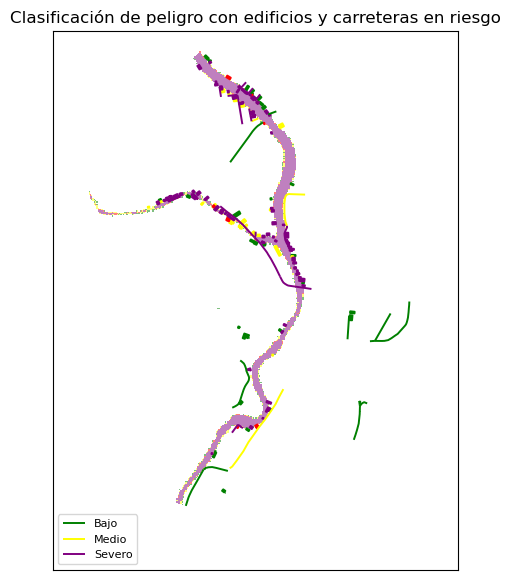

In [7]:
from rasterio.transform import array_bounds

NATIVE = f"{BUCKET}/Guatemala_IBF/guatemala_flood_30cm_probability_clipped.tif"

with rasterio.open(NATIVE) as ds:
    native_crs = ds.crs
geo = gpd.read_file(f"{BUCKET}/Guatemala_IBF/impact_features.geojson").to_crs(native_crs)

grid_crs = meta["30cm"]["crs"]
rows, cols = meta["30cm"]["shape"]
left, bottom, right, top = array_bounds(rows, cols, meta["30cm"]["transform"])

# El mismo CRS, o las dos capas no se alinearán.
geo_grid = geo.to_crs(grid_crs)
geo_grid["hazard"] = classify_features(
    geo_grid.assign(**{f: geo_grid[f].fillna(0.0) for f in PROB_FIELDS}), GATES
)

fig, ax = plt.subplots(figsize=(8, 7))

# Normal y NoData quedan transparentes para que las áreas clasificadas se lean bien.
shaded = np.where((hazard > 0) & (hazard != NODATA), hazard, np.nan).astype("float32")
ax.imshow(shaded, cmap=cmap, norm=norm, interpolation="nearest",
          extent=(left, right, bottom, top), alpha=0.5)

for value, colour in LEVELS:
    subset = geo_grid[geo_grid.hazard == value]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=1.4, edgecolor=colour,
                    label=LEVEL_LABEL[value])

ax.set_xlim(left, right)
ax.set_ylim(bottom, top)
ax.set_title("Clasificación de peligro con edificios y carreteras en riesgo")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower left", fontsize=8)
plt.show()

## 6. Cómo lo hacen los módulos del tablero

Tres módulos se construyen sobre la regla de la sección 2. Igual que en el
Ejercicio 2, el cálculo no cambia: esto es la envoltura que lo hace descubrible y
configurable.

### Descubrimiento

Cada módulo es una clase registrada como **punto de entrada de Intake**, que es lo
único que lo hace visible para TethysDash. Note que cada módulo se publica dos veces,
una por idioma:

```toml
[project.entry-points."intake.drivers"]
wmo_impact_summary_en = "tgf_wmo_plugins.impact_summary:ImpactSummaryEN"
wmo_impact_summary_es = "tgf_wmo_plugins.impact_summary:ImpactSummaryES"
wmo_hazard_layer_en   = "tgf_wmo_plugins.hazard_layer:HazardLayerEN"
wmo_hazard_layer_es   = "tgf_wmo_plugins.hazard_layer:HazardLayerES"
wmo_impact_layer_en   = "tgf_wmo_plugins.impact_layer:ImpactLayerEN"
wmo_impact_layer_es   = "tgf_wmo_plugins.impact_layer:ImpactLayerES"
```

### La clase: propiedades de descubrimiento, argumentos y un método

```python
from tethysapp.tethysdash.plugin_helpers import TethysDashPlugin


class ImpactSummaryES(TethysDashPlugin):

    # ---- descubrimiento: cómo lista y presenta este módulo la interfaz ----
    name = "wmo_impact_summary_es"          # debe coincidir con el punto de entrada
    label = "Resumen de Impacto (Español)"  # la fila del desplegable
    group = "Mapas de Inundación (Español)" # el encabezado donde va
    description = "Personas, edificios y carreteras en cada nivel de peligro."
    tags = ["inundación", "impacto", "IBF", "exposición", "tabla", "español"]

    # ---- qué tipo de visualización es ------------------------------------
    type = "table"
    # `type` elige el renderizador de la interfaz y, por lo tanto, dicta la forma
    # que run() debe devolver. Uno de: table, card, plotly, image, text,
    # variable_input, map, map_layer, custom.

    # ---- qué le pide la interfaz a quien arma el tablero ------------------
    args = {
        "umbral_bajo":   "number",    # umbral de P(>= 7.6 cm)
        "umbral_medio":  "number",    # P(>= 10 cm)
        "umbral_alto":   "number",    # P(>= 30 cm)
        "umbral_severo": "number",    # P(>= 76 cm)
    }
    # "number" genera un campo numérico; una lista de {"value", "label"} generaría
    # un desplegable. La interfaz deriva la etiqueta de cada campo del nombre del
    # argumento, separando por guiones bajos y capitalizando, así que
    # `umbral_bajo` se muestra como "Umbral Bajo", sin ninguna tabla de
    # traducción aparte.

    def run(self):
        """Se llama una vez por solicitud, y otra vez cuando cambia un argumento."""

        gates = self.gates()
        # gates() llama a get_arg() una vez por umbral. get_arg() lee un valor
        # configurado y, si quien armó el tablero vinculó ese argumento a una
        # variable de entrada, la referencia "${Umbral Bajo ...}" ya está resuelta
        # a esta altura: el módulo nunca ve la plantilla.

        df = classify_features(load_features(), gates)
        # ^ secciones 2 y 3: los mismos umbrales escalonados, aplicados a los
        #   elementos.

        return {"title": "Resumen de Impacto",
                "data": [{"Nivel": "...", "Edificios": "...", "Población": "..."}]}
```

### Los argumentos son parte del contrato público

Los *nombres* de los argumentos son las claves que guarda un tablero, lo que los
convierte en una interfaz publicada y no en un detalle de implementación. Eso forzó
una decisión aquí: los módulos en inglés exponen nombres en inglés
(`low_threshold`, `medium_threshold`, ...) y los módulos en español declaran
`umbral_bajo` / `umbral_medio` / `umbral_alto` / `umbral_severo`.

Dos consecuencias que conviene entender, porque las dos fallan en silencio:

- Un argumento que un módulo **no** declara simplemente no existe en tiempo de
  ejecución; no lanza ningún error. Si le pasa `umbral_bajo` al módulo en inglés,
  todos los umbrales vuelven calladamente a su valor por defecto: el tablero carga
  bien y los controles parecen no hacer nada.
- Renombrar un argumento rompe todos los tableros que ya estaban vinculados al
  nombre anterior, exactamente de esa forma silenciosa. Elija los nombres antes de
  publicar.

Internamente, los umbrales se indexan por **valor de clase**, nunca por nombre:

```python
THRESHOLD_ARGS = {
    "en": {1: "low_threshold", 2: "medium_threshold",
           3: "high_threshold", 4: "severe_threshold"},
    "es": {1: "umbral_bajo", 2: "umbral_medio",
           3: "umbral_alto", 4: "umbral_severo"},
}


def gates(self):
    """-> {1: 0.8, 2: 0.8, 3: 0.8, 4: 0.2} -- indexado por valor de clase."""
    names = THRESHOLD_ARGS[self.LANG]
    # get_arg() por cada nombre, convertido a float, con el valor por defecto del
    # cuaderno cuando un umbral está vacío o no se puede interpretar.
    return {value: ... for value in (1, 2, 3, 4)}
```

`gates[1]` en lugar de `gates["Bajo"]` es justamente el punto: una sola
implementación sirve para los dos idiomas, y una traducción nunca puede alcanzar la
clasificación.

### Las capas de mapa implementan dos métodos, no uno

```python
class HazardLayerES(TethysDashPlugin):
    name = "wmo_hazard_layer_es"
    label = "Capa de Peligro (Español)"
    group = "Mapas de Inundación (Español)"
    type = "map_layer"
    dynamic_map_layer = True     # esta bandera habilita fetch_features()
    args = {...}                 # los mismos cuatro umbrales

    def run(self):
        """Momento de CONFIGURACIÓN. Una vez, al agregar la capa.

        Devuelve el armazón: nombre, vinculación de la fuente, reglas de estilo y
        leyenda. Es lo que llama el botón "Fetch plugin defaults".
        """
        builder = LayerConfigurationBuilder("Clasificación de peligro", "GeoJSON")
        builder.set_plugin_source(self.name, self.received_args)
        # received_args, no self.args: el esquema no son los valores configurados,
        # y las vinculaciones "${Umbral Bajo ...}" deben sobrevivir para
        # resolverse en cada consulta.
        builder.set_style(...)    # cuatro reglas sobre el atributo `peligro`
        builder.set_legend(...)
        return builder.build()

    def fetch_features(self):
        """Momento de EJECUCIÓN. Al cargar y con cada cambio de un umbral."""
        gates = self.gates()

        self.send_update("Leyendo los rásteres...", percentage_complete=10)
        layers, transform, crs = ...            # los cuatro rásteres de probabilidad

        self.send_update("Clasificando...", percentage_complete=50)
        peligro = clasificar_peligro(*layers, gates)   # sección 2, sin cambios

        self.send_update("Generando polígonos...", percentage_complete=75)
        # Una capa de mapa solo puede apuntar a una URL y aquí nada sirve un ráster
        # calculado, así que la cuadrícula clasificada se vectoriza: cada tramo
        # contiguo de la misma clase se vuelve un polígono, unos 600 en total.
        # Normal y NoData se descartan, cerca del 90% de la cuadrícula, y nada que
        # un mapa base no muestre ya.
        features = ...

        return {"type": "FeatureCollection", "features": features,
                "crs": {"type": "name", "properties": {"name": str(crs)}}}
```

### Los tres módulos

| módulo | `type` | qué devuelve |
|---|---|---|
| `wmo_impact_summary_*` | `table` | `{"title", "data": [filas]}` — la tabla de la sección 4 |
| `wmo_hazard_layer_*` | `map_layer` | el armazón de `run()`; la cuadrícula clasificada y vectorizada de `fetch_features()` |
| `wmo_impact_layer_*` | `map_layer` | el armazón de `run()`; los elementos clasificados de la sección 3 |

### Por qué vale la pena separar los dos métodos

`run()` se ejecuta una vez, cuando alguien está configurando el tablero.
`fetch_features()` se ejecuta con cada cambio de un umbral vinculado. Poner el estilo
y la leyenda en `run()` significa que se calculan una sola vez y se guardan con el
tablero, así que mover un umbral vuelve a ejecutar solo la parte que realmente
depende de él.

`wmo_impact_summary_*` nunca toca los rásteres. Los edificios y las carreteras ya
traen las cuatro probabilidades, así que aplica los mismos umbrales a un CSV
reducido, exactamente como hizo la sección 3. El geopaquete completo pesa 37.7 MB y
tarda unos 160 s en leerse por la red, lo que es inviable una vez por solicitud.

### Cosas para probar

- Ponga los cuatro umbrales en el mismo valor en la sección 2 y vuelva a ejecutar
  las secciones 3 a 5. ¿Se vuelve más fácil de explicar el mapa?
- Suba el umbral Severo por encima de 0.2 y confirme que la clase desaparece tanto de
  la tabla como del mapa. ¿Cómo evitaría que alguien hiciera esto por accidente?
- El Ejercicio 2 respondía "qué tan profunda es el agua en la tormenta 150"; este
  responde "cuál es la probabilidad de 30 cm". Los dos usan los mismos edificios sobre
  la misma cuadrícula. ¿Cuál pondría frente a un oficial de protección civil, y qué
  diría del otro?